In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_raw = pd.read_csv('/content/drive/MyDrive/Churn_Prediction_Project/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df = df_raw.copy()

#1. Basic dataset check

In [ ]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#2. Data types + missing values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


#3. Check TotalCharges

In [ ]:
print("Blank TotalCharges:",
      (df['TotalCharges'].str.strip() == '').sum())

Blank TotalCharges: 11


In [ ]:
df[df['TotalCharges'].str.strip() == ''][[
    'customerID',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Churn'
]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


#4. Clean TotalCharges

In [ ]:
df['TotalCharges'] = df['TotalCharges'].str.strip()

In [ ]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [ ]:
print("Missing TotalCharges:",
      df['TotalCharges'].isnull().sum())

Missing TotalCharges: 11


In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [ ]:
print("Missing TotalCharges:",
      df['TotalCharges'].isnull().sum())

print("Data type:",
      df['TotalCharges'].dtype)

Missing TotalCharges: 0
Data type: float64


#5. Check target variable - Churn

In [ ]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
print(df['Churn'].value_counts(normalize=True).mul(100).round(2))

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


#6. Numerical summary

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


#7. Separate ML dataset

In [ ]:
df_ml = df.drop(columns=['customerID'])

In [ ]:
print(df_ml.shape)

(7043, 20)


#8. Exploratory Data Analysis (EDA)

**8.1 Churn Distribution**

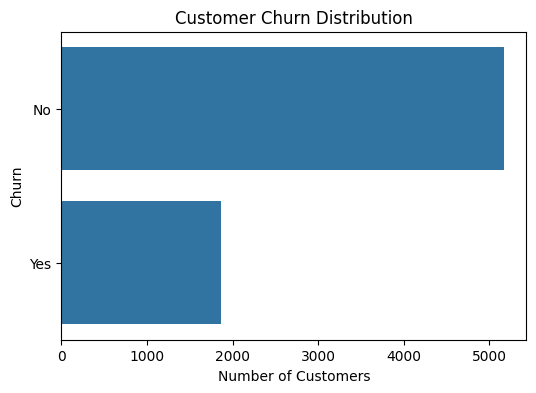

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, y='Churn')

plt.title('Customer Churn Distribution')
plt.ylabel('Churn')
plt.xlabel('Number of Customers')

plt.show()

**8.2 Contract Type vs Churn**

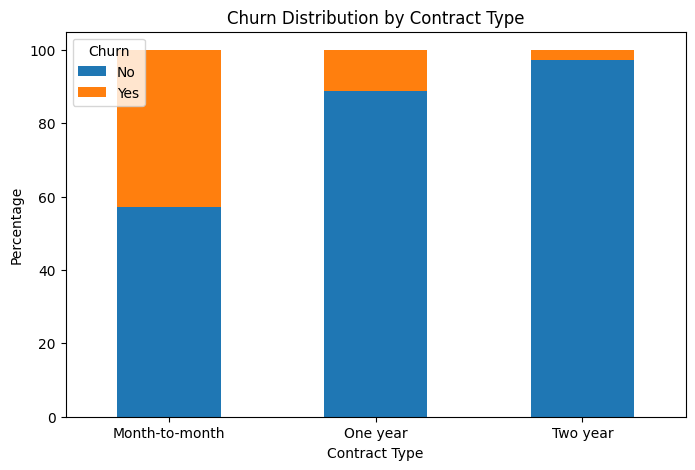

In [ ]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Churn Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

**8.3 Monthly Charges vs Churn**

In [ ]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


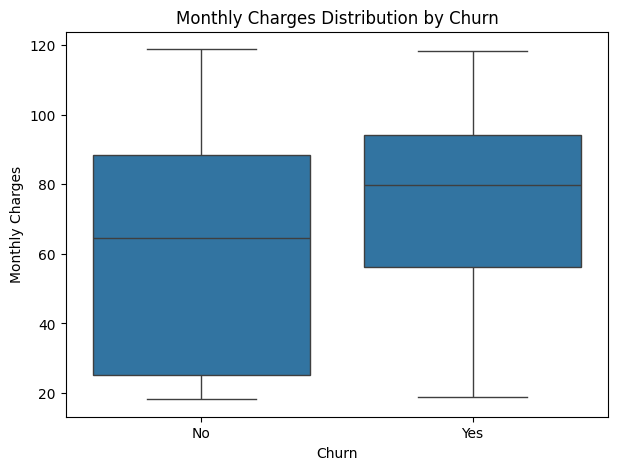

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

**8.4 Internet Service vs Churn**

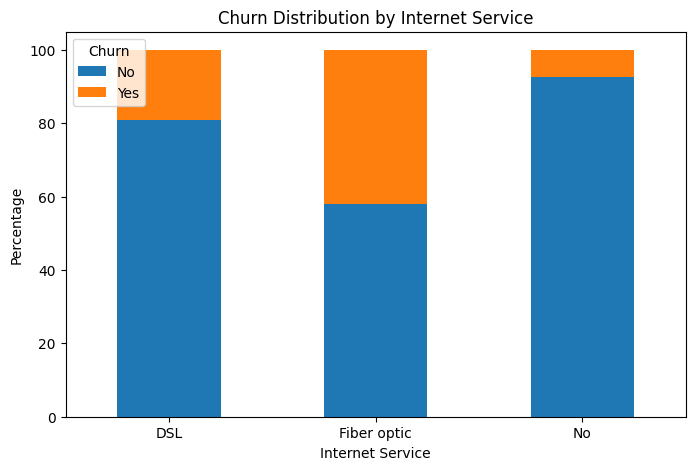

In [ ]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

internet_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Churn Distribution by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

**8.5 Payment Method vs Churn**

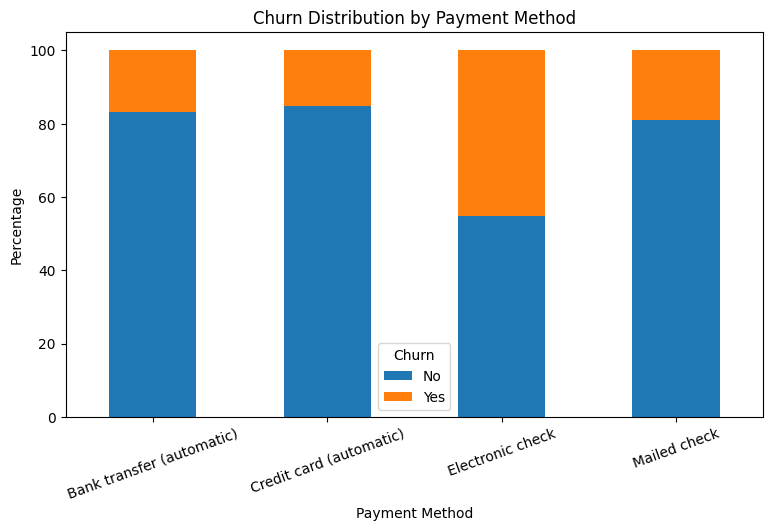

In [ ]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5)
)

plt.title('Churn Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Percentage')
plt.xticks(rotation=20)
plt.legend(title='Churn')
plt.show()

**8.6 Tenure vs Churn**

In [ ]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


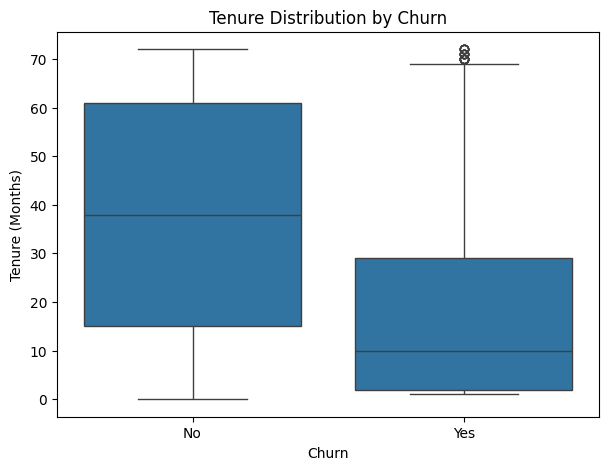

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='Churn', y='tenure')

plt.title('Tenure Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

**8.7 Senior Citizen vs Churn**

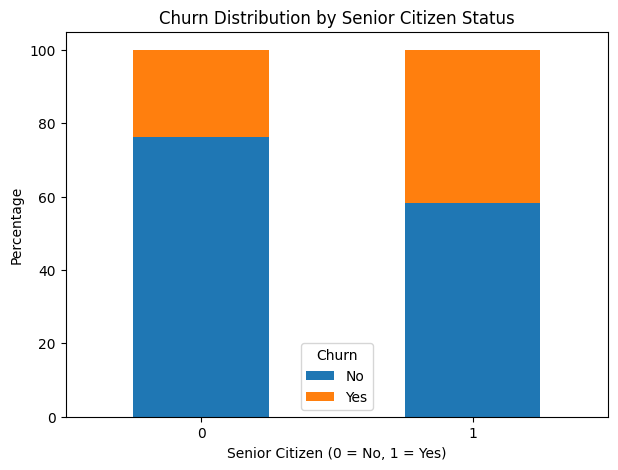

In [ ]:
senior_churn = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

senior_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title('Churn Distribution by Senior Citizen Status')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

In [ ]:
print(df['TotalCharges'].dtype)

object


**Error Handling(Total Charges)**

In [ ]:
df['TotalCharges'] = df['TotalCharges'].str.strip()

In [ ]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [ ]:
print(df['TotalCharges'].isnull().sum())
print(df['TotalCharges'].dtype)

11
float64


In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [ ]:
print(df['TotalCharges'].isnull().sum())
print(df['TotalCharges'].dtype)

0
float64



**8.8 Total Charges vs Churn**

In [ ]:
df.groupby('Churn')['TotalCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


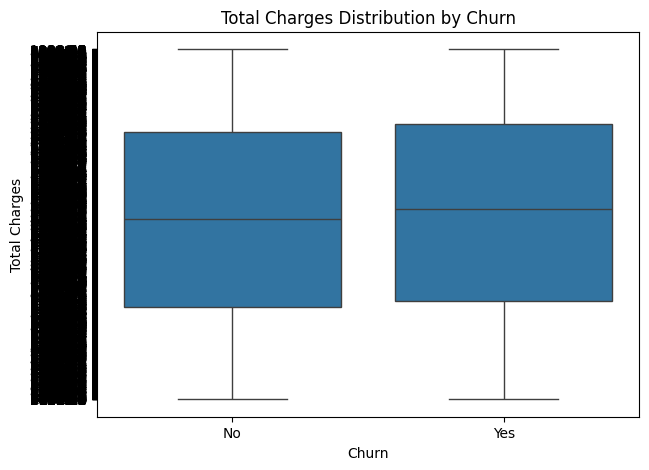

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='TotalCharges'
)

plt.title('Total Charges Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges')

plt.show()

**8.9 Tenure vs Total Charges**

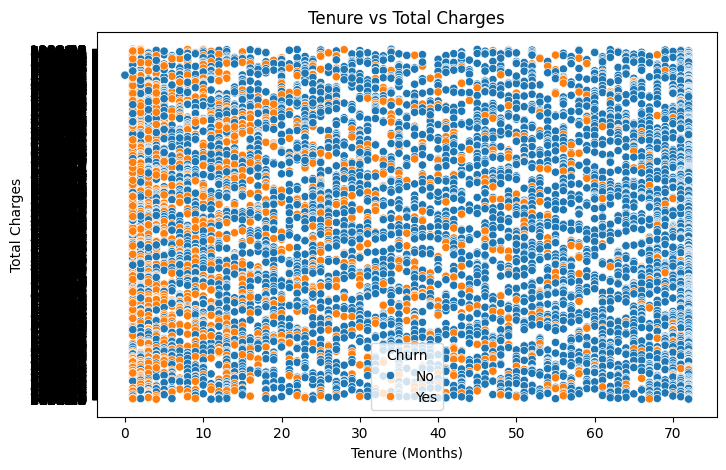

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='tenure',
    y='TotalCharges',
    hue='Churn'
)

plt.title('Tenure vs Total Charges')
plt.xlabel('Tenure (Months)')
plt.ylabel('Total Charges')

plt.show()

#9. Feature Engineering


In [ ]:
df_ml.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print(df_ml.dtypes)

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No inter

#10. Encoding

In [3]:
# Fresh ML dataset
df_ml = df.drop(columns=['customerID']).copy()

# Clean TotalCharges
df_ml['TotalCharges'] = df_ml['TotalCharges'].str.strip()

df_ml['TotalCharges'] = pd.to_numeric(
    df_ml['TotalCharges'],
    errors='coerce'
)

df_ml['TotalCharges'] = df_ml['TotalCharges'].fillna(0)


# Binary encoding
df_ml['gender'] = df_ml['gender'].map({
    'Male': 1,
    'Female': 0
})

for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    df_ml[col] = df_ml[col].map({
        'Yes': 1,
        'No': 0
    })


# One-hot encoding
multi_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df_ml = pd.get_dummies(
    df_ml,
    columns=multi_cols,
    drop_first=True,
    dtype=int
)


# Encode target
df_ml['Churn'] = df_ml['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [4]:
print(df_ml[['gender', 'Partner', 'Dependents',
             'PhoneService', 'PaperlessBilling']].isnull().sum())

print("\nTotal missing:", df_ml.isnull().sum().sum())

print("\nObject columns:")
print(df_ml.select_dtypes(include='object').columns.tolist())

gender              0
Partner             0
Dependents          0
PhoneService        0
PaperlessBilling    0
dtype: int64

Total missing: 0

Object columns:
[]


#11. Define Input and Output Variables

In [5]:
X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

In [6]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 30)
y shape: (7043,)


#12. Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify = y
)


In [8]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 30)
X_test : (1409, 30)
y_train: (5634,)
y_test : (1409,)


In [9]:
print("Training churn distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training churn distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing churn distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


#13. Model Training

In [10]:
from sklearn.linear_model import LogisticRegression

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

#14. Model Evaluation

In [13]:
y_pred = log_model.predict(X_test_scaled)

print(y_pred[:10])

[0 1 0 0 0 1 0 0 0 0]


In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8069552874378992


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[925 110]
 [162 212]]


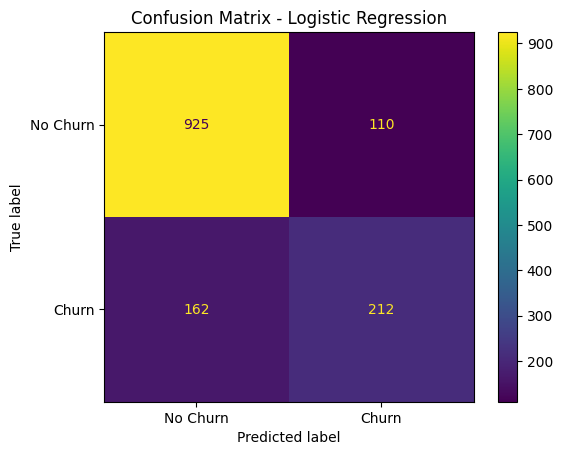

In [17]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot()

plt.title('Confusion Matrix - Logistic Regression')
plt.show()

#15. Model Comparison


**15.1 Decision Tree**

In [18]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [19]:
#Prediction
dt_pred = dt_model.predict(X_test)

In [20]:
#Evaluation
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1035
           1       0.49      0.48      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



**15.2 Random Forest**

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [22]:
#Prediction
rf_pred = rf_model.predict(X_test)

In [23]:
#Evaluation
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



**15.3 Model Comparison Summary**

In [24]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.81, 0.73, 0.79],
    'Churn Recall': [0.57, 0.48, 0.50],
    'Churn F1': [0.61, 0.49, 0.56]
})

print(results)

                 Model  Accuracy  Churn Recall  Churn F1
0  Logistic Regression      0.81          0.57      0.61
1        Decision Tree      0.73          0.48      0.49
2        Random Forest      0.79          0.50      0.56


**15.4 Model Improvement — Balanced Logistic Regression**

In [25]:
log_model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [26]:
#Prediction
y_pred_balanced = log_model_balanced.predict(X_test_scaled)

In [27]:
#Evaluation
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



**15.5 Model Comparison — Updated**

In [28]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Balanced Logistic Regression'],
    'Accuracy': [0.81, 0.73, 0.79, 0.74],
    'Churn Recall': [0.57, 0.48, 0.50, 0.79],
    'Churn F1-Score': [0.61, 0.49, 0.56, 0.62]
})
print(results)

                          Model  Accuracy  Churn Recall  Churn F1-Score
0           Logistic Regression      0.81          0.57            0.61
1                 Decision Tree      0.73          0.48            0.49
2                 Random Forest      0.79          0.50            0.56
3  Balanced Logistic Regression      0.74          0.79            0.62


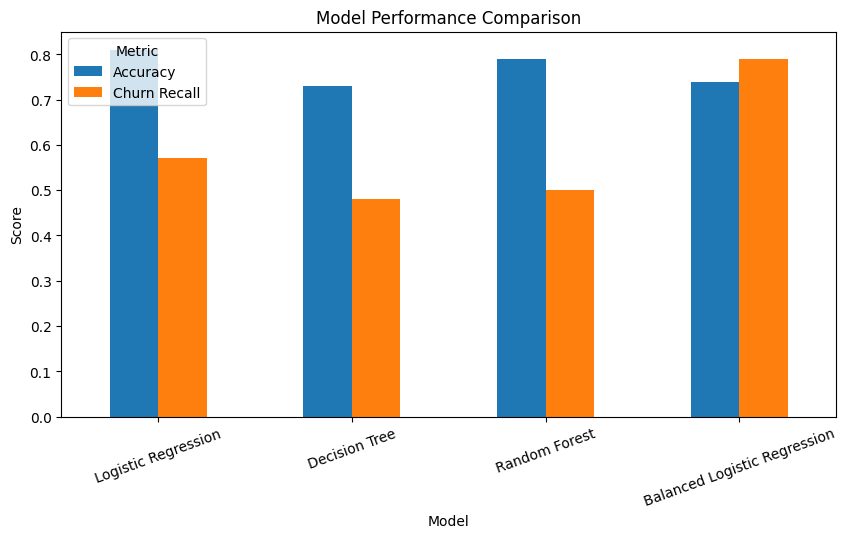

In [29]:
results.plot(
    x='Model',
    y=['Accuracy', 'Churn Recall'],
    kind='bar',
    figsize=(10, 5)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=20)
plt.legend(title='Metric')
plt.show()

#16. Final Model Selection

In [30]:
final_model = log_model_balanced

print("Final Model: Balanced Logistic Regression")

Final Model: Balanced Logistic Regression


#17. Final Model Evaluation

In [31]:
#Prediction
final_pred = final_model.predict(X_test_scaled)

In [32]:
#Classification Report
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [33]:
#Confusion Matrix
final_cm = confusion_matrix(y_test, final_pred)

print(final_cm)

[[749 286]
 [ 80 294]]


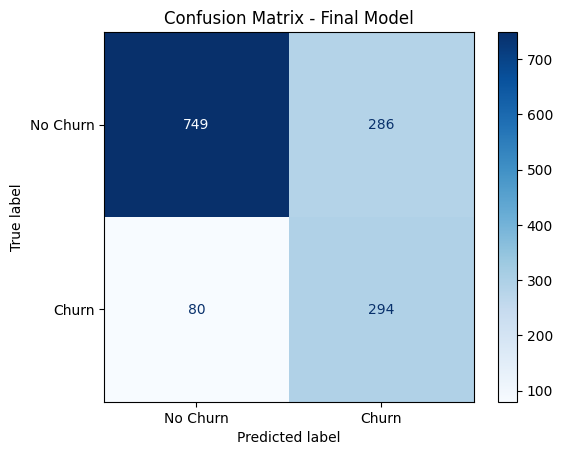

In [34]:
#Confusion Matrix Visualization
disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot(cmap='Blues')

plt.title('Confusion Matrix - Final Model')
plt.show()

#18. Feature Importance / Model Interpretation

**18.1 Feature Importance**

In [35]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': final_model.coef_[0]
})

feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()

feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
4,tenure,-1.159048,1.159048
7,MonthlyCharges,-1.039440,1.039440
11,InternetService_Fiber optic,0.808897,0.808897
26,Contract_Two year,-0.617746,0.617746
8,TotalCharges,0.494748,0.494748
25,Contract_One year,-0.296706,0.296706
24,StreamingMovies_Yes,0.285948,0.285948
22,StreamingTV_Yes,0.273209,0.273209
10,MultipleLines_Yes,0.201165,0.201165
28,PaymentMethod_Electronic check,0.188783,0.188783


**18.2 Feature Importance Visualization**

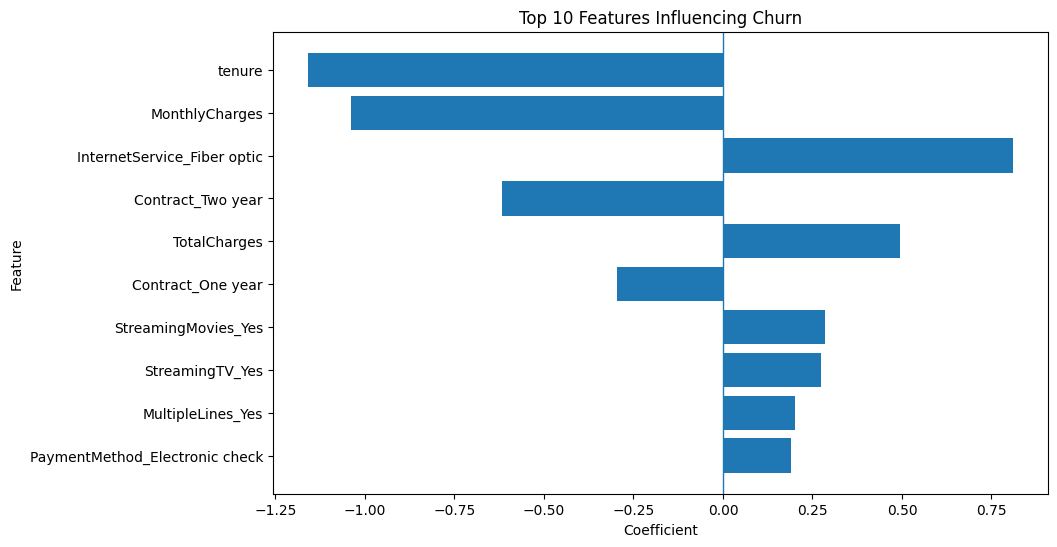

In [36]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Top 10 Features Influencing Churn')

plt.axvline(0, linewidth=1)

plt.gca().invert_yaxis()

plt.show()

#19. Customer Churn Prediction

In [37]:
churn_probability = final_model.predict_proba(X_test_scaled)[:, 1]

prediction_results = pd.DataFrame({
    'Actual Churn': y_test.values,
    'Predicted Churn': final_pred,
    'Churn Probability': churn_probability
})

prediction_results['Churn Probability'] = (
    prediction_results['Churn Probability'] * 100
).round(2)

prediction_results.head(10)

,Actual Churn,Predicted Churn,Churn Probability
0,0,0,11.84
1,0,1,85.16
2,0,0,14.13
3,0,1,66.49
4,0,0,6.14
5,0,1,80.54
6,0,1,69.95
7,0,0,29.38
8,0,0,0.88
9,1,1,65.22


#20. Export Prediction Results

In [38]:
prediction_results.to_csv(
    'churn_prediction_results.csv',
    index=False
)

In [ ]:
from google.colab import files

files.download('churn_prediction_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
powerbi_data = X_test.copy()

powerbi_data['Actual Churn'] = y_test.values
powerbi_data['Predicted Churn'] = final_pred
powerbi_data['Churn Probability'] = churn_probability

In [40]:
powerbi_data.to_csv(
    'churn_powerbi_dataset.csv',
    index=False
)

#21. Create Power BI Dataset

In [41]:
powerbi_data = df.loc[X_test.index].copy()

powerbi_data['Predicted Churn'] = final_pred
powerbi_data['Churn Probability'] = churn_probability

powerbi_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Predicted Churn,Churn Probability
437,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2,No,0,0.118378
2280,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,No,1,0.851640
2235,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.2,No,0,0.141315
4460,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,No,1,0.664935
3761,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,No,0,0.061424


In [42]:
powerbi_data.shape

(1409, 23)

In [ ]:
powerbi_data.to_csv(
    'churn_powerbi_dataset.csv',
    index=False
)

In [43]:
from google.colab import files

files.download('churn_powerbi_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>